import packages

In [679]:
import os
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
from collections import defaultdict
import escher
from escher import Builder
import cobra
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import re
from re import match
import numpy as np
from cobra.flux_analysis import flux_variability_analysis
from cobra import Reaction

workflow

load dataset -> check the data information (metabolites name) -> setup the control environment -> calculate each analyse (growth rate)

load dataset and set the save path

In [680]:
# State the path to the file.xml
sbml_fname = 'P_stutzeri_1018.xml'
# Read the model
model = read_sbml_model(sbml_fname)
reference = "https://doi.org/10.1016/j.synbio.2023.10.001."
# Create save folder
save_path = f"Results_{sbml_fname.replace('.xml','')}"
os.makedirs(save_path, exist_ok=True)

print("Model ID:", model.id)
print("Model Name:", model.name)
print("Metabolites:", len(model.metabolites))
print("Reactions:", len(model.reactions))
print("Genes:", len(model.genes))
print("Current objective:", model.objective)

# Show first 10 genes
for gene in list(model.genes)[:10]:
    print("ID:", gene.id)
    print("Name:", gene.name)
    print()

Model ID: iQY1018
Model Name: iQY1018
Metabolites: 1203
Reactions: 1420
Genes: 1018
Current objective: Maximize
1.0*biomass0 - 1.0*biomass0_reverse_9c18d
ID: PST_1808
Name: G_PST_1808

ID: PST_1807
Name: G_PST_1807

ID: PST_3534
Name: G_PST_3534

ID: PST_3533
Name: G_PST_3533

ID: PST_3535
Name: G_PST_3535

ID: PST_3520
Name: G_PST_3520

ID: PST_1877
Name: G_PST_1877

ID: PST_1875
Name: G_PST_1875

ID: PST_1876
Name: G_PST_1876

ID: PST_1649
Name: G_PST_1649



In [681]:
model

Name,iQY1018
Memory address,2132869dc10
Number of metabolites,1203
Number of reactions,1420
Number of genes,1018
Number of groups,0
Objective expression,1.0*biomass0 - 1.0*biomass0_reverse_9c18d
Compartments,"c0, e0"


In [682]:
model.reactions

[<Reaction rxn08094 at 0x2133995ba10>,
 <Reaction rxn01637 at 0x2133868edb0>,
 <Reaction rxn01644 at 0x2133868e8e0>,
 <Reaction rxn02928 at 0x2133868ed00>,
 <Reaction rxn01652 at 0x2133868f070>,
 <Reaction rxn00684 at 0x2133868efc0>,
 <Reaction rxn05782 at 0x2133868e570>,
 <Reaction rxn00979 at 0x2133868dff0>,
 <Reaction rxn08653 at 0x2133868f330>,
 <Reaction rxn00127 at 0x2133868f490>,
 <Reaction EXpd02791 at 0x2133868f540>,
 <Reaction ADD_12dia at 0x2133868f5f0>,
 <Reaction ADD_TPP1 at 0x2133868f750>,
 <Reaction rxn02484 at 0x2133868f800>,
 <Reaction ADD_TPP3 at 0x2133868f8b0>,
 <Reaction ADD_TPP4 at 0x2133868f960>,
 <Reaction rxn42709 at 0x2133868fa10>,
 <Reaction EXpd01042 at 0x2133868fac0>,
 <Reaction EXpd03091 at 0x2133868fb70>,
 <Reaction ADD_TPP8 at 0x2133868fc20>,
 <Reaction rxn05147 at 0x2133868fcd0>,
 <Reaction rxn00154 at 0x2133868fd80>,
 <Reaction rxn25164 at 0x2133868fe30>,
 <Reaction rxn01258 at 0x2133868fee0>,
 <Reaction rxn10880 at 0x21342f84050>,
 <Reaction rxn10859 a

In [683]:
print(model.summary())
[r for r in model.reactions if r.objective_coefficient == 1]

Objective
1.0 biomass0 = 0.8109884016567651

Uptake
------
 Metabolite  Reaction   Flux  C-Number  C-Flux
cpd00007_e0 EXpd00007  26.28         0   0.00%
cpd00009_e0 EXpd00009 0.8017         0   0.00%
cpd00013_e0 EXpd00013  8.377         0   0.00%
cpd00027_e0 EXpd00027     10         6 100.00%
cpd00048_e0 EXpd00048 0.1719         0   0.00%

Secretion
---------
 Metabolite   Reaction      Flux  C-Number C-Flux
 biomass_e0 EX_Biomass    -0.811         0  0.00%
cpd00001_e0  EXpd00001    -48.85         0  0.00%
cpd00011_e0  EXpd00011    -27.69         1 99.84%
cpd00067_c0  EXpd00068    -6.092         0  0.00%
cpd02791_c0  EXpd02791 -0.007218         6  0.16%



[<Reaction biomass0 at 0x21342f86150>]

In [684]:
print(model.metabolites)

[<Metabolite cpd02096_c0 at 0x2132fc620d0>, <Metabolite cpd00693_c0 at 0x2132fc614f0>, <Metabolite cpd00066_e0 at 0x2132fc60cd0>, <Metabolite cpd11512_c0 at 0x2132fc60870>, <Metabolite cpd15422_c0 at 0x2132fc60730>, <Metabolite cpd00226_c0 at 0x2132fc62490>, <Metabolite cpd15796_c0 at 0x2132fc63ed0>, <Metabolite cpd00001_c0 at 0x2132fc60690>, <Metabolite cpd03586_c0 at 0x2132fc60e10>, <Metabolite cpd00557_c0 at 0x2132fc63070>, <Metabolite cpd11640_c0 at 0x2132fc63250>, <Metabolite cpd08287_c0 at 0x2132fc61db0>, <Metabolite cpd11544_c0 at 0x2132fc605f0>, <Metabolite cpd01262_c0 at 0x2132fc62670>, <Metabolite cpd00751_e0 at 0x2132fc60a50>, <Metabolite cpd11537_c0 at 0x2132fc602d0>, <Metabolite cpd12237_c0 at 0x2132fc60ff0>, <Metabolite cpd02074_c0 at 0x2132fc62170>, <Metabolite cpd01974_c0 at 0x2132fc60c30>, <Metabolite cpd00007_e0 at 0x2132fc62ad0>, <Metabolite cpd00241_c0 at 0x2132fc600f0>, <Metabolite cpd00724_c0 at 0x2132fc61bd0>, <Metabolite cpd05262_e0 at 0x2132fc60f50>, <Metabolit

In [685]:
model.reactions

[<Reaction rxn08094 at 0x2133995ba10>,
 <Reaction rxn01637 at 0x2133868edb0>,
 <Reaction rxn01644 at 0x2133868e8e0>,
 <Reaction rxn02928 at 0x2133868ed00>,
 <Reaction rxn01652 at 0x2133868f070>,
 <Reaction rxn00684 at 0x2133868efc0>,
 <Reaction rxn05782 at 0x2133868e570>,
 <Reaction rxn00979 at 0x2133868dff0>,
 <Reaction rxn08653 at 0x2133868f330>,
 <Reaction rxn00127 at 0x2133868f490>,
 <Reaction EXpd02791 at 0x2133868f540>,
 <Reaction ADD_12dia at 0x2133868f5f0>,
 <Reaction ADD_TPP1 at 0x2133868f750>,
 <Reaction rxn02484 at 0x2133868f800>,
 <Reaction ADD_TPP3 at 0x2133868f8b0>,
 <Reaction ADD_TPP4 at 0x2133868f960>,
 <Reaction rxn42709 at 0x2133868fa10>,
 <Reaction EXpd01042 at 0x2133868fac0>,
 <Reaction EXpd03091 at 0x2133868fb70>,
 <Reaction ADD_TPP8 at 0x2133868fc20>,
 <Reaction rxn05147 at 0x2133868fcd0>,
 <Reaction rxn00154 at 0x2133868fd80>,
 <Reaction rxn25164 at 0x2133868fe30>,
 <Reaction rxn01258 at 0x2133868fee0>,
 <Reaction rxn10880 at 0x21342f84050>,
 <Reaction rxn10859 a

to see the metabolites name or id name

In [686]:
#model.metabolites.get_by_id('cpd00007[e0]').name

In [687]:
matches = [m for m in model.metabolites if 'nit' in m.name.lower()]
for m in matches:
    print(m.id, m.name)

cpd00209_c0 Nitrate
cpd03646_c0 gamma-Glutamyl-3-aminopropiononitrile
cpd00331_c0 cis-Aconitate
cpd00314_e0 D-Mannitol
cpd00209_e0 Nitrate
cpd00342_c0 N-Acetylornithine
cpd02160_c0 N2-Succinyl-L-ornithine
cpd18071_c0 Ethylnitronate
cpd00314_c0 D-Mannitol
cpd00075_e0 Nitrite
cpd00659_c0 Nitrous oxide
cpd15665_c0 Peptidoglycan polymer (n subunits)
cpd00064_c0 Ornithine
cpd00064_e0 Ornithine
cpd02597_c0 cis-2-Methylaconitate
cpd00075_c0 Nitrite


rename

In [688]:

# Exchange reactions
for reaction in model.exchanges:
    if len(reaction.metabolites) == 1:
        metabolite = list(reaction.metabolites.keys())[0]        
        new_id = f"EX_{metabolite.id}"

        if new_id not in model.reactions:
            print(f"Renaming: {reaction.id} -> {new_id}")
            reaction.id = new_id
        else:
            print(f"Skipped {reaction.id} because {new_id} already exists.")

# Save the modified model
filename = f"Renamed_{sbml_fname}"
full_destination = os.path.join(save_path, filename)
cobra.io.write_sbml_model(model, full_destination)
print(f"Model successfully saved to: {full_destination}")

Renaming: EXpd02791 -> EX_cpd02791_c0
Renaming: EXpd01042 -> EX_cpd01042_c0
Renaming: EXpd03091 -> EX_cpd03091_c0
Renaming: EXpd11590 -> EX_cpd11590_e0
Renaming: EXpd16062 -> EX_cpd16062_e0
Renaming: EXpd00156 -> EX_cpd00156_e0
Renaming: EXpd11583 -> EX_cpd11583_e0
Renaming: EXpd01242 -> EX_cpd01242_e0
Renaming: EXpd00254 -> EX_cpd00254_e0
Renaming: EXpd15603 -> EX_cpd15603_e0
Renaming: EXpd11576 -> EX_cpd11576_e0
Renaming: EXpd00098 -> EX_cpd00098_e0
Renaming: EXpd00971 -> EX_cpd00971_e0
Renaming: EXpd00023 -> EX_cpd00023_e0
Renaming: EXpd03424 -> EX_cpd03424_e0
Renaming: EXpd00205 -> EX_cpd00205_e0
Renaming: EXpd00034 -> EX_cpd00034_e0
Renaming: EXpd00009 -> EX_cpd00009_e0
Renaming: EXpd15606 -> EX_cpd15606_e0
Renaming: EXpd00048 -> EX_cpd00048_e0
Renaming: EXpd00039 -> EX_cpd00039_e0
Renaming: EXpd00106 -> EX_cpd00106_e0
Renaming: EXpd00264 -> EX_cpd00264_e0
Renaming: EXpd01171 -> EX_cpd01171_e0
Renaming: EXpd00211 -> EX_cpd00211_e0
Renaming: EXpd00129 -> EX_cpd00129_e0
Renaming: EX

changes model name 

In [689]:
model.name = "Pseudomonas stutzeri"

exchange reaction

In [690]:
model.metabolites

[<Metabolite cpd02096_c0 at 0x2132fc620d0>,
 <Metabolite cpd00693_c0 at 0x2132fc614f0>,
 <Metabolite cpd00066_e0 at 0x2132fc60cd0>,
 <Metabolite cpd11512_c0 at 0x2132fc60870>,
 <Metabolite cpd15422_c0 at 0x2132fc60730>,
 <Metabolite cpd00226_c0 at 0x2132fc62490>,
 <Metabolite cpd15796_c0 at 0x2132fc63ed0>,
 <Metabolite cpd00001_c0 at 0x2132fc60690>,
 <Metabolite cpd03586_c0 at 0x2132fc60e10>,
 <Metabolite cpd00557_c0 at 0x2132fc63070>,
 <Metabolite cpd11640_c0 at 0x2132fc63250>,
 <Metabolite cpd08287_c0 at 0x2132fc61db0>,
 <Metabolite cpd11544_c0 at 0x2132fc605f0>,
 <Metabolite cpd01262_c0 at 0x2132fc62670>,
 <Metabolite cpd00751_e0 at 0x2132fc60a50>,
 <Metabolite cpd11537_c0 at 0x2132fc602d0>,
 <Metabolite cpd12237_c0 at 0x2132fc60ff0>,
 <Metabolite cpd02074_c0 at 0x2132fc62170>,
 <Metabolite cpd01974_c0 at 0x2132fc60c30>,
 <Metabolite cpd00007_e0 at 0x2132fc62ad0>,
 <Metabolite cpd00241_c0 at 0x2132fc600f0>,
 <Metabolite cpd00724_c0 at 0x2132fc61bd0>,
 <Metabolite cpd05262_e0 at 0x21

In [691]:
n2_search = [r.id for r in model.reactions if "cpd00528" in r.id]
nif_search = [r.id for r in model.reactions if "nif" in r.id.lower() or "nitrogenase" in r.name.lower() or "rxn00557" in r.id]
print(f"Correct N2 Exchange ID: {n2_search}")
print(f"Correct Nitrogenase ID: {nif_search}")

Correct N2 Exchange ID: ['EX_cpd00528_c0']
Correct Nitrogenase ID: []


In [692]:
exchange_rows = []
with open(os.path.join(save_path, "boundary_list.txt"), "w") as f:
    header = f"{'exchange_id':30s} | {'reaction_name':30s} | {'lower_bound':12s} | {'upper_bound'}"
    f.write(header + "\n" + "-"*90 + "\n")
    for r in model.boundary:
        line = f"{r.id:30s} | {r.name:30s} | {r.lower_bound:<12} | {r.upper_bound}"
        f.write(line + "\n")
        
        exchange_rows.append({
            "exchange_id": r.id, 
            "reaction_name": r.name,
            "lower_bound": r.lower_bound, 
            "upper_bound": r.upper_bound
        })
        
boundary_df = pd.DataFrame(exchange_rows)
csv_file = os.path.join(save_path, "boundary_reactions.csv")
tsv_file = os.path.join(save_path, "boundary_reactions.tsv")

boundary_df.to_csv(csv_file, index=False)
boundary_df.to_csv(tsv_file, sep='\t', index=False)

print(f"Successfully saved {len(boundary_df)} boundary reactions to {save_path}")

# Check nitrogen fixation reactions
nif_ids = [
    "EX_cpd00528_c0", # N2 exchange
    "EX_cpd00209_e0", # Nitrate exchange
    "EX_cpd00075_e0", # Nitrite exchange
    "EX_cpd00659_c0", # Nitrous oxide exchange
    "EX_cpd00013_e0", # Ammonia exchange
    "rxn00557_c0"     # Nitrogenase enzyme
]

for rid in nif_ids:
    try:
        r = model.reactions.get_by_id(rid)
        print(f"{rid:25s} | {r.name}")
    except KeyError:
        base_id = rid.split('_')[1] if 'cpd' in rid else rid
        suggestions = [r.id for r in model.reactions if base_id in r.id]
        print(f"{rid:25s} | NOT FOUND (Suggestions: {suggestions[:2]})")

Successfully saved 140 boundary reactions to Results_P_stutzeri_1018
EX_cpd00528_c0            | 
EX_cpd00209_e0            | 
EX_cpd00075_e0            | NOT FOUND (Suggestions: [])
EX_cpd00659_c0            | NOT FOUND (Suggestions: [])
EX_cpd00013_e0            | 
rxn00557_c0               | NOT FOUND (Suggestions: [])


In [693]:
print(model.summary())
[r for r in model.reactions if r.objective_coefficient == 1]

Objective
1.0 biomass0 = 0.8109884016559767

Uptake
------
 Metabolite       Reaction   Flux  C-Number  C-Flux
cpd00007_e0 EX_cpd00007_e0  26.28         0   0.00%
cpd00009_e0 EX_cpd00009_e0 0.8017         0   0.00%
cpd00013_e0 EX_cpd00013_e0  8.377         0   0.00%
cpd00027_e0 EX_cpd00027_e0     10         6 100.00%
cpd00048_e0 EX_cpd00048_e0 0.1719         0   0.00%

Secretion
---------
 Metabolite       Reaction      Flux  C-Number C-Flux
 biomass_e0     EX_Biomass    -0.811         0  0.00%
cpd00001_e0 EX_cpd00001_e0    -48.85         0  0.00%
cpd00011_e0 EX_cpd00011_e0    -27.69         1 99.84%
cpd00067_c0 EX_cpd00067_c0    -6.092         0  0.00%
cpd02791_c0 EX_cpd02791_c0 -0.007218         6  0.16%



[<Reaction biomass0 at 0x21342f86150>]

In [694]:
reaction_df = pd.DataFrame([{
    'id': r.id, 
    'name': r.name, 
    'genes': r.gene_name_reaction_rule
} for r in model.reactions])

print(reaction_df.head())

         id                                               name  \
0  rxn08094                       2-Oxogluterate dehydrogenase   
1  rxn01637  N2-Acetyl-L-ornithine:2-oxoglutarate aminotran...   
2  rxn01644  L-Aspartate-4-semialdehyde hydro-lyase (adding...   
3  rxn02928  2,3,4,5-Tetrahydrodipicolinate:NAD+ oxidoreduc...   
4  rxn01652  S-Aminomethyldihydrolipoylprotein:(6S)-tetrahy...   

                                               genes  
0  (G_PST_1875 and G_PST_1877 and G_PST_1876) or ...  
1                                         G_PST_1649  
2                                         G_PST_2790  
3                                         G_PST_3325  
4                                         G_PST_4064  


In [695]:
met_df = pd.DataFrame([{
    'id': m.id, 
    'name': m.name, 
    'formula': m.formula, 
    'compartment': m.compartment
} for m in model.metabolites])

print(met_df.head())

            id                                name        formula compartment
0  cpd02096_c0               L-3-Amino-isobutyrate        C4H9NO2          c0
1  cpd00693_c0                      D-Lactaldehyde         C3H6O2          c0
2  cpd00066_e0                     L-Phenylalanine       C9H11NO2          e0
3  cpd11512_c0  12-methyl-3-oxo-tetra-decanoyl-ACP  C26H47N2O9PRS          c0
4  cpd15422_c0  CDP-1,2-ditetradec-7-enoylglycerol  C40H67N3O15P2          c0


In [696]:
# Reaction List
r_data = []
for r in model.reactions:
    r_data.append({
        "current_id": r.id,
        "name": r.name,
        "reaction_string": r.build_reaction_string(),
        "subsystem": r.subsystem,
        "lower_bound": r.lower_bound,
        "upper_bound": r.upper_bound,
        "suggested_new_id": ""  
    })

# Metabolite List
met_data = []
for m in model.metabolites:
    met_data.append({
        "current_id": m.id,
        "name": m.name,
        "formula": m.formula,
        "compartment": m.compartment,
        "charge": m.charge,
        "suggested_new_id": ""  # Fill this in Excel for renaming
    })

# Convert to DataFrames
df_r = pd.DataFrame(r_data)
df_mets = pd.DataFrame(met_data)
r_file = os.path.join(save_path,f"{sbml_fname.replace('.xml','')}_reactions_for_mapping.csv")
met_file = os.path.join(save_path,f"{sbml_fname.replace('.xml','')}_metabolites_for_mapping.csv")
df_r.to_csv(r_file, index=False)
df_mets.to_csv(met_file, index=False)

print(f"Exported {len(df_r)} reactions and {len(df_mets)} metabolites to your files.")

Exported 1420 reactions and 1203 metabolites to your files.


fine biomass

In [697]:
biomass_candidates = [r.id for r in model.reactions if "biomass" in r.id.lower()]

if not biomass_candidates:
    raise ValueError("No biomass reaction found!")

biomass_rxn = biomass_candidates[0]
print("\nUsing biomass reaction:", biomass_rxn)

model.objective = biomass_rxn


Using biomass reaction: biomass0


from the 752 workshop week 7 copy the model

In [698]:
model_bulk = model.copy()
print("Objective bulk soil:", model_bulk.objective)
model_rh = model.copy()
print("Objective rhizoshere:", model_rh.objective)
model_no = model.copy()
print("Objective nodule:", model_no.objective)

Objective bulk soil: Maximize
1.0*biomass0 - 1.0*biomass0_reverse_9c18d
Objective rhizoshere: Maximize
1.0*biomass0 - 1.0*biomass0_reverse_9c18d
Objective nodule: Maximize
1.0*biomass0 - 1.0*biomass0_reverse_9c18d


set the environment control

soil environment from https://doi.org/10.1038/ncomms12219

table https://static-content.springer.com/esm/art%3A10.1038%2Fncomms12219/MediaObjects/41467_2016_BFncomms12219_MOESM588_ESM.pdf 

To set the start control for all the sample as the same environment 

setup the code or name in each metabolites depend on each sample


bulk soil environment

In [699]:
for r in model_bulk.exchanges:
    r.lower_bound=0

# bulk soil 60 
exchange_bounds_bulk = {
    'EX_cpd00224_e0': -0.28889705,    #L-arabinose
    'EX_cpd00108_e0': -0.25290619,    #D-galactose 
    'EX_cpd00027_e0': -0.61972444,    #D-glucose 
    'EX_cpd00138_e0': -0.2540567,     #D-mannose 
    'EX_cpd00396_e0': -0.13913636,    #L-rhamnose 
    'EX_cpd00154_e0': -0.21280795,    #Xylose
    'EX_cpd00105_e0': -0.01862144,    #D-ribose
    'EX_cpd00076_e0': 0,              #Sucrose
    'EX_cpd00382_e0': 0,              #D-raffinose 
    'EX_cpd01133_e0': 0,              #Stachyose
    'EX_cpd00036_e0': -0.0056245,     #Succinate
    'EX_cpd00130_e0': -0.03649016,    #L-malate 
    'EX_cpd00041_e0': 0,              #L-aspartate 
    'EX_cpd00161_e0': -0.0068175,     #L-threonine 
    'EX_cpd00054_e0': 0,              #L-serine
    'EX_cpd00023_e0': 0,              #L-glutamate 
    'EX_cpd00129_e0': -0.01102953,    #L-proline 
    'EX_cpd00033_e0': -0.0068175,     #Glycine 
    'EX_cpd00035_e0': -0.02780553,    #L-alanine
    'EX_cpd00156_e0': -0.02928849,    #L-valine 
    'EX_cpd00084_e0': -0.0068175,     #L-cysteine 
    'EX_cpd00322_e0': -0.0199273,     #L-isoleucine 
    'EX_cpd00107_e0': -0.03596182,    #L-leucine 
    'EX_cpd00069_e0': -0.0068175,     #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': -0.0068175,     #L-ornithine 
    'EX_cpd00119_e0': -0.0068175,     #L-histidine 
    'EX_cpd00051_e0': -0.0068175,     #L-arginine 
    'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': -7.5,           #Ammonia 
    'EX_cpd00209_e0': -7.5,           #Nitrate
    'EX_cpd00048_e0': -15,            #Sulfate
    'EX_cpd00009_e0': -15,            #Phosphate
    'EX_cpd00001_e0': -15,            #H2O
    'EX_cpd00007_e0': -15,            #O2
    'EX_cpd00011_e0': -15,            #CO2
    'EX_cpd00030_e0': -15,            #Mn2
    'EX_cpd00034_e0': -15,            #Zn2
    'EX_cpd00058_e0': -15,            #Cu2
    'EX_cpd00063_e0': -15,            #Ca2
    'EX_cpd00067_e0': -15,            #H+  
    'EX_cpd00099_e0': -15,            #Cl- 
    'EX_cpd00104_e0': -15,            #Biotin
    'EX_cpd00149_e0': -15,            #Co2
    'EX_cpd00205_e0': -15,            #K+
    'EX_cpd00254_e0': -15,            #Mg2+
    'EX_cpd00971_e0': -15,            #Na+
    'EX_cpd10515_e0': -15,            #Fe2+ 
    'EX_cpd10516_e0': -15,            #Fe3+
    'EX_cpd00635_e0': 0,              #Cob(I)alamin
    'EX_cpd00919_e0': 0,              #Homocitrate
    'EX_cpd11574_e0': 0,              #Molybdate
    'EX_cpd00305_e0': 0,              #Thiamine
    'EX_cpd00121_e0': 0,              #M-inositol 
    'EX_cpd00528_e0': 0,              #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': 0               #Fixed NH3
}

print("Setting exchange bounds:")
for comp_id, bound in exchange_bounds_bulk.items():
    if comp_id in model_bulk.reactions:
        model_bulk.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds:


rhizoshere environment

In [700]:
for r in model_rh.exchanges:
    r.lower_bound=0

# rhizoshere soil 60 
exchange_bounds_rh = {
    'EX_cpd00224_e0': -0.26974143,    #L-arabinose
    'EX_cpd00108_e0': -0.18317325,    #D-galactose 
    'EX_cpd00027_e0': -0.04098397,    #D-glucose 
    'EX_cpd00138_e0': -0.05436649,    #D-mannose 
    'EX_cpd00396_e0': -0.02927426,    #L-rhamnose 
    'EX_cpd00154_e0': -0.04600242,    #Xylose
    'EX_cpd00105_e0': 0,              #D-ribose
    'EX_cpd00076_e0': -0.02049199,    #Sucrose
    'EX_cpd00382_e0': -0.01024599,    #D-raffinose 
    'EX_cpd01133_e0': -0.03073798,    #Stachyose
    'EX_cpd00036_e0': -0.12240603,    #Succinate
    'EX_cpd00130_e0': -0.79413596,    #L-malate 
    'EX_cpd00041_e0': -0.03205557,    #L-aspartate 
    'EX_cpd00161_e0': -0.00961667,    #L-threonine 
    'EX_cpd00054_e0': -0.01004986,    #L-serine
    'EX_cpd00023_e0': -0.0283302,     #L-glutamate 
    'EX_cpd00129_e0': 0,              #L-proline 
    'EX_cpd00033_e0': -0.00693094,    #Glycine 
    'EX_cpd00035_e0': -0.00823049,    #L-alanine
    'EX_cpd00156_e0': -0.00337883,    #L-valine 
    'EX_cpd00084_e0': 0,              #L-cysteine 
    'EX_cpd00322_e0': -0.00186269,    #L-isoleucine 
    'EX_cpd00107_e0': -0.00303228,    #L-leucine 
    'EX_cpd00069_e0': -0.00233919,    #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': -0.00831712,    #L-ornithine 
    'EX_cpd00119_e0': -0.00506825,    #L-histidine 
    'EX_cpd00051_e0': -0.00948672,    #L-arginine 
    'EX_cpd00851_e0': -0.26974144,    #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': -7.5,           #Ammonia 
    'EX_cpd00209_e0': -7.5,           #Nitrate
    'EX_cpd00048_e0': -15,            #Sulfate
    'EX_cpd00009_e0': -15,            #Phosphate
    'EX_cpd00001_e0': -15,            #H2O
    'EX_cpd00007_e0': -15,            #O2
    'EX_cpd00011_e0': -15,            #CO2
    'EX_cpd00030_e0': -15,            #Mn2
    'EX_cpd00034_e0': -15,            #Zn2
    'EX_cpd00058_e0': -15,            #Cu2
    'EX_cpd00063_e0': -15,            #Ca2
    'EX_cpd00067_e0': -15,            #H+  
    'EX_cpd00099_e0': -15,            #Cl- 
    'EX_cpd00104_e0': -15,            #Biotin
    'EX_cpd00149_e0': -15,            #Co2
    'EX_cpd00205_e0': -15,            #K+
    'EX_cpd00254_e0': -15,            #Mg2+
    'EX_cpd00971_e0': -15,            #Na+
    'EX_cpd10515_e0': -15,            #Fe2+ 
    'EX_cpd10516_e0': -15,            #Fe3+
    'EX_cpd00635_e0': 0,              #Cob(I)alamin
    'EX_cpd00919_e0': 0,              #Homocitrate
    'EX_cpd11574_e0': 0,              #Molybdate
    'EX_cpd00305_e0': 0,              #Thiamine
    'EX_cpd00121_e0': 0,              #M-inositol 
    'EX_cpd00528_e0': 0,              #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': 0               #Fixed NH3
}

print("Setting exchange bounds rhizosphere:")
for comp_id, bound in exchange_bounds_rh.items():
    if comp_id in model_rh.reactions:
        model_rh.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds rhizosphere:


nodule environment

In [701]:
for r in model_no.exchanges:
    r.lower_bound=0

# nodule soil 60 
exchange_bounds_no = {
    'EX_cpd00224_e0': 0,              #L-arabinose
    'EX_cpd00108_e0': 0,              #D-galactose 
    'EX_cpd00027_e0': 0,              #D-glucose 
    'EX_cpd00138_e0': 0.,             #D-mannose 
    'EX_cpd00396_e0': 0.,             #L-rhamnose 
    'EX_cpd00154_e0': 0.,             #Xylose
    'EX_cpd00105_e0': 0.,             #D-ribose
    'EX_cpd00076_e0': 0,              #Sucrose
    'EX_cpd00382_e0': 0,              #D-raffinose 
    'EX_cpd01133_e0': 0,              #Stachyose
    'EX_cpd00036_e0': -1.326,         #Succinate
    'EX_cpd00130_e0': -1.1122,        #L-malate 
    'EX_cpd00041_e0': 0,              #L-aspartate 
    'EX_cpd00161_e0': 0,              #L-threonine 
    'EX_cpd00054_e0': 0,              #L-serine
    'EX_cpd00023_e0': -2,             #L-glutamate 
    'EX_cpd00129_e0': 0,              #L-proline 
    'EX_cpd00033_e0': 0.,             #Glycine 
    'EX_cpd00035_e0': 0.,             #L-alanine
    'EX_cpd00156_e0': 0.,             #L-valine 
    'EX_cpd00084_e0': 0,              #L-cysteine 
    'EX_cpd00322_e0': 0,              #L-isoleucine 
    'EX_cpd00107_e0': 0,              #L-leucine 
    'EX_cpd00069_e0': 0,              #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': 0,              #L-ornithine 
    'EX_cpd00119_e0': 0,              #L-histidine 
    'EX_cpd00051_e0': 0,              #L-arginine 
    'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': 0,              #Ammonia 
    'EX_cpd00209_e0': 0,              #Nitrate
    'EX_cpd00048_e0': -1000,          #Sulfate
    'EX_cpd00009_e0': -1000,          #Phosphate
    'EX_cpd00001_e0': -1000,          #H2O
    'EX_cpd00007_e0': -1.26,          #O2
    'EX_cpd00011_e0': -1000,          #CO2
    'EX_cpd00030_e0': 0,              #Mn2
    'EX_cpd00034_e0': 0,              #Zn2
    'EX_cpd00058_e0': 0,              #Cu2
    'EX_cpd00063_e0': 0,              #Ca2
    'EX_cpd00067_e0': -1000,          #H+  
    'EX_cpd00099_e0': 0,              #Cl- 
    'EX_cpd00104_e0': 0,              #Biotin
    'EX_cpd00149_e0': 0,              #Co2
    'EX_cpd00205_e0': 0,              #K+
    'EX_cpd00254_e0': -1000,          #Mg2+
    'EX_cpd00971_e0': 0,              #Na+
    'EX_cpd10515_e0': -1000,          #Fe2+ 
    'EX_cpd10516_e0': 0,              #Fe3+
    'EX_cpd00635_e0': -1000,          #Cob(I)alamin
    'EX_cpd00919_e0': -1000,          #Homocitrate
    'EX_cpd11574_e0': -1000,          #Molybdate
    'EX_cpd00305_e0': -1000,          #Thiamine
    'EX_cpd00121_e0': -0.01,          #M-inositol 
    'EX_cpd00528_e0': -1000,          #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': 0               #Fixed NH3
}

print("Setting exchange bounds nodule:")
for comp_id, bound in exchange_bounds_no.items():
    if comp_id in model_no.reactions:
        model_no.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds nodule:


calculate

In [702]:
solution_bulk = model_bulk.optimize()

In [703]:
solution_rh = model_rh.optimize()

In [704]:
solution_no = model_no.optimize()

In [705]:
for name, sol in [("Bulk soil", solution_bulk), ("Rhizosphere", solution_rh), ("Nodule", solution_no)]:
    gr = sol.objective_value if sol.status == "optimal" else "INFEASIBLE"
    print(f"  {name:12s} | status: {sol.status:8s} | growth rate: {gr}")

  Bulk soil    | status: optimal  | growth rate: 0.05955506865765379
  Rhizosphere  | status: optimal  | growth rate: 0.042283755083592334
  Nodule       | status: optimal  | growth rate: 0.1936272995904218


save data

growth rate summary

In [706]:
summary_rows = []
for cond_name, sol in [( "Bulk", solution_bulk),
                       ("Rhizosphere", solution_rh),
                       ("Nodule", solution_no)]:
    
    if sol.status == "optimal":
        gr      = sol.objective_value
        nif     = sol.fluxes.get("rxn06874_c0",   0.0)   # nitrogenase
        n2_up   = sol.fluxes.get("EX_cpd00528_e0",0.0)   # N2 uptake
        nh3_ex  = sol.fluxes.get("EX_cpd00013_e0",0.0)   # NH3 exchange
        fixed   = sol.fluxes.get("EX_cpdFixed_e0",0.0)   # fixed NH3 export
        o2_up   = sol.fluxes.get("EX_cpd00007_e0",0.0)   # O2 uptake
        doublt  = round(0.693147 / gr, 4) if gr > 0 else None
    else:
        gr = nif = n2_up = nh3_ex = fixed = o2_up = doublt = None

    summary_rows.append({
        "Species":              model.name,
        "Condition":            cond_name,
        "Status":               sol.status,
        "Growth_rate_h":        round(gr,    6) if gr    is not None else None,
        "Doubling_time_h":      doublt,
        "Nitrogenase_flux":     round(nif,   6) if nif   is not None else None,
        "N2_uptake":            round(abs(n2_up), 6),
        "NH3_exchange":         round(nh3_ex,6),
        "FixedNH3_export":      round(fixed, 6),
        "O2_uptake":            round(abs(o2_up), 6),
        "Reference":            reference,
    })

summary_df = pd.DataFrame(summary_rows)

# Save
summary_file = os.path.join(save_path, "growth_rate_summary.tsv")
summary_df.to_csv(summary_file, sep="\t", index=False)

print(summary_df.to_string(index=False))
print(f"\nSaved {summary_file}")


             Species   Condition  Status  Growth_rate_h  Doubling_time_h  Nitrogenase_flux  N2_uptake  NH3_exchange  FixedNH3_export  O2_uptake                                     Reference
Pseudomonas stutzeri        Bulk optimal       0.059555          11.6388               0.0        0.0     -0.444950              0.0   2.125749 https://doi.org/10.1016/j.synbio.2023.10.001.
Pseudomonas stutzeri Rhizosphere optimal       0.042284          16.3927               0.0        0.0     -0.287739              0.0   1.749537 https://doi.org/10.1016/j.synbio.2023.10.001.
Pseudomonas stutzeri      Nodule optimal       0.193627           3.5798               0.0        0.0      0.000000              0.0   1.260000 https://doi.org/10.1016/j.synbio.2023.10.001.

Saved Results_P_stutzeri_1018\growth_rate_summary.tsv


full flux tables 

In [707]:
# Save complete flux table for each condition
for cond_name, sol, model_cond in [
        ("bulk",        solution_bulk, model_bulk),
        ("rhizosphere", solution_rh,   model_rh),
        ("nodule",      solution_no,   model_no),
]:
    if sol.status != "optimal":
        print(f"  {cond_name}: skipped (infeasible)")
        continue

    flux_df = sol.to_frame().reset_index()
    flux_df.columns = ["reaction_id", "flux", "reduced_cost"]

    # Add readable reaction name
    flux_df["reaction_name"] = flux_df["reaction_id"].apply(
        lambda rid: model_cond.reactions.get_by_id(rid).name
        if rid in model_cond.reactions else ""
    )

    # Add condition column
    flux_df.insert(0, "condition", cond_name)

    # Save
    fname = os.path.join(save_path, f"{cond_name}_fluxes.tsv")
    flux_df.to_csv(fname, sep="\t", index=False)
    print(f"  Saved {len(flux_df)} reactions  {fname}")


  Saved 1420 reactions  Results_P_stutzeri_1018\bulk_fluxes.tsv
  Saved 1420 reactions  Results_P_stutzeri_1018\rhizosphere_fluxes.tsv
  Saved 1420 reactions  Results_P_stutzeri_1018\nodule_fluxes.tsv


exchanges fluxes

In [708]:
exchange_rows = []

for cond_name, sol, model_cond in [
        ("Bulk",        solution_bulk, model_bulk),
        ("Rhizosphere", solution_rh,   model_rh),
        ("Nodule",      solution_no,   model_no),
]:
    if sol.status != "optimal":
        continue

    for rxn in model_cond.exchanges:
        flux = sol.fluxes.get(rxn.id, 0.0)
        if abs(flux) > 1e-9:          # only active exchanges
            exchange_rows.append({
                "condition":     cond_name,
                "reaction_id":   rxn.id,
                "reaction_name": rxn.name,
                "flux":          round(flux, 8),
                "direction":     "uptake" if flux < 0 else "secretion",
            })

ex_df = pd.DataFrame(exchange_rows)
ex_file = os.path.join(save_path, "exchange_fluxes_all_conditions.tsv")
ex_df.to_csv(ex_file, sep="\t", index=False)

print(f"Saved {len(ex_df)} active exchange fluxes → {ex_file}")
print()
# Show top 10 per condition
for cond in ["Bulk", "Rhizosphere", "Nodule"]:
    sub = ex_df[ex_df.condition == cond].sort_values("flux", key=abs, ascending=False).head(5)
    print(f"  {cond} — top 5 active exchanges:")
    print(sub[["reaction_name","flux","direction"]].to_string(index=False))
    print()


Saved 55 active exchange fluxes → Results_P_stutzeri_1018\exchange_fluxes_all_conditions.tsv

  Bulk — top 5 active exchanges:
reaction_name       flux direction
               15.206594 secretion
              -15.000000    uptake
                3.459717 secretion
                2.183911 secretion
               -2.125749    uptake

  Rhizosphere — top 5 active exchanges:
reaction_name       flux direction
              -15.000000    uptake
               13.292963 secretion
                2.718162 secretion
                2.661283 secretion
               -1.749537    uptake

  Nodule — top 5 active exchanges:
reaction_name        flux direction
              -109.988507    uptake
               106.401160 secretion
                 4.106468 secretion
                 3.641643 secretion
                -2.000000    uptake



gene lists

In [709]:
# Save gene list for each condition model
for cond_name, model_cond in [
        ("bulk",        model_bulk),
        ("rhizosphere", model_rh),
        ("nodule",      model_no),
]:
    gene_data = [{
        "gene_id":       g.id,
        "gene_name":     g.name,
        "n_reactions":   len(g.reactions),
        "reaction_ids":  ";".join(r.id for r in g.reactions),
    } for g in model_cond.genes]

    gene_file = os.path.join(save_path, f"{cond_name}_genes.tsv")
    pd.DataFrame(gene_data).to_csv(gene_file, sep="\t", index=False)
    print(f"  Saved {len(gene_data)} genes  {gene_file}")


  Saved 1018 genes  Results_P_stutzeri_1018\bulk_genes.tsv
  Saved 1018 genes  Results_P_stutzeri_1018\rhizosphere_genes.tsv
  Saved 1018 genes  Results_P_stutzeri_1018\nodule_genes.tsv


biomass over time 

In [710]:
# X(t) = X0 * exp(µ * t)
X0      = 0.01                          # inoculum g/L
t_hours = np.arange(0, 73, 1)          # 0 to 72 hours

time_rows = []
for cond_name, sol in [("Bulk",        solution_bulk),
                        ("Rhizosphere", solution_rh),
                        ("Nodule",      solution_no)]:

    mu = sol.objective_value if sol.status == "optimal" else 0.0
    for t in t_hours:
        time_rows.append({
            "species":    "S. meliloti",
            "condition":  cond_name,
            "time_h":     t,
            "mu":         round(mu, 6),
            "biomass_gL": round(X0 * np.exp(mu * t), 8),
        })

time_df = pd.DataFrame(time_rows)
time_file = os.path.join(save_path, "biomass_over_time.tsv")
time_df.to_csv(time_file, sep="\t", index=False)
print(f"Saved {len(time_df)} rows → {time_file}")

# Show biomass at key timepoints
for cond in ["Bulk", "Rhizosphere", "Nodule"]:
    sub = time_df[time_df.condition == cond]
    for t in [0, 12, 24, 48, 72]:
        row = sub[sub.time_h == t].iloc[0]
        print(f"  {cond:12s} | t={t:2d}h | µ={row.mu:.5f} | X={row.biomass_gL:.5f} g/L")
    print()


Saved 219 rows → Results_P_stutzeri_1018\biomass_over_time.tsv
  Bulk         | t= 0h | µ=0.05955 | X=0.01000 g/L
  Bulk         | t=12h | µ=0.05955 | X=0.02043 g/L
  Bulk         | t=24h | µ=0.05955 | X=0.04176 g/L
  Bulk         | t=48h | µ=0.05955 | X=0.17438 g/L
  Bulk         | t=72h | µ=0.05955 | X=0.72818 g/L

  Rhizosphere  | t= 0h | µ=0.04228 | X=0.01000 g/L
  Rhizosphere  | t=12h | µ=0.04228 | X=0.01661 g/L
  Rhizosphere  | t=24h | µ=0.04228 | X=0.02759 g/L
  Rhizosphere  | t=48h | µ=0.04228 | X=0.07611 g/L
  Rhizosphere  | t=72h | µ=0.04228 | X=0.20998 g/L

  Nodule       | t= 0h | µ=0.19363 | X=0.01000 g/L
  Nodule       | t=12h | µ=0.19363 | X=0.10212 g/L
  Nodule       | t=24h | µ=0.19363 | X=1.04277 g/L
  Nodule       | t=48h | µ=0.19363 | X=108.73788 g/L
  Nodule       | t=72h | µ=0.19363 | X=11338.90923 g/L



plot

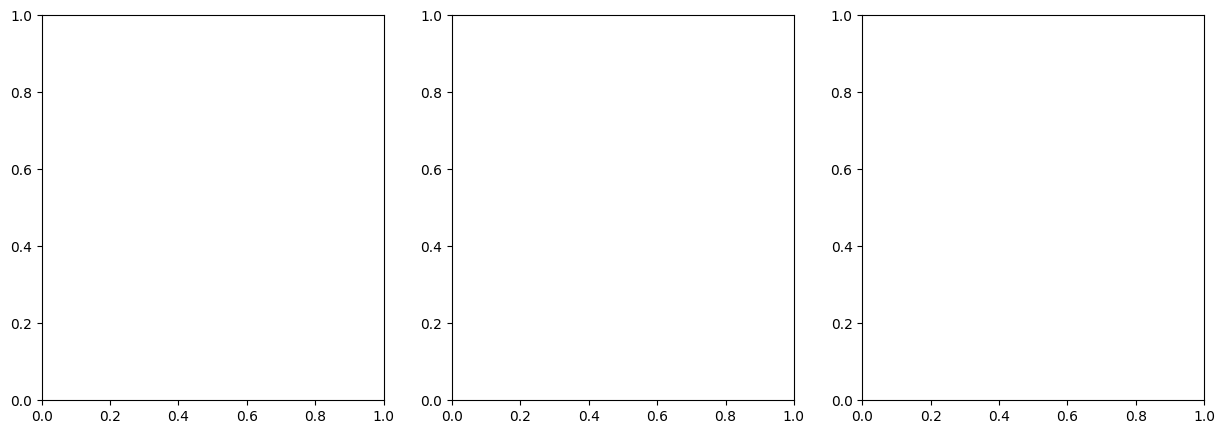

In [711]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS = {"Bulk": "#0C447C", "Rhizosphere": "#378ADD", "Nodule": "#444441"}
conds = ["Bulk", "Rhizosphere", "Nodule"]
species_name = re.sub(r'\d+', '', model.name.replace("_", " ")).strip()

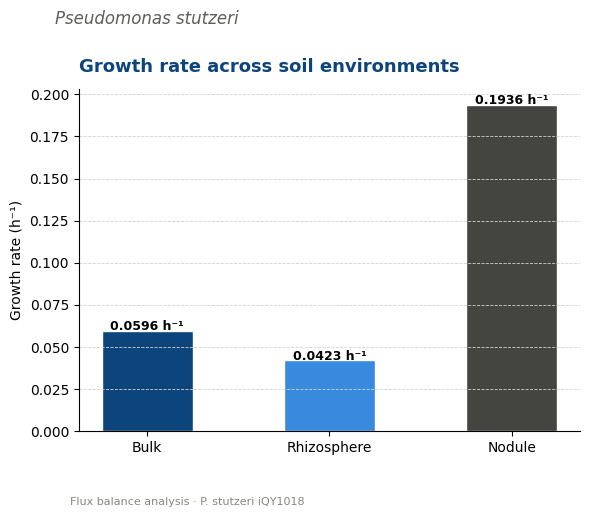

In [712]:
# Plot 1: growth rate bar 
fig1, ax = plt.subplots(figsize=(6, 5))
vals = [summary_df[summary_df.Condition==c]["Growth_rate_h"].values[0]
        if summary_df[summary_df.Condition==c]["Status"].values[0]=="optimal" else 0
        for c in conds]
bars = ax.bar(conds, vals, color=[COLORS[c] for c in conds], edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.4f} h⁻¹", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Growth rate (h⁻¹)")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Growth rate across soil environments",
             fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig1.text(0.125, -0.04,
          "Flux balance analysis · P. stutzeri iQY1018",
          fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
fig1.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig1.savefig(os.path.join(save_path, "1_growth_rate.png"), dpi=300)
plt.show()

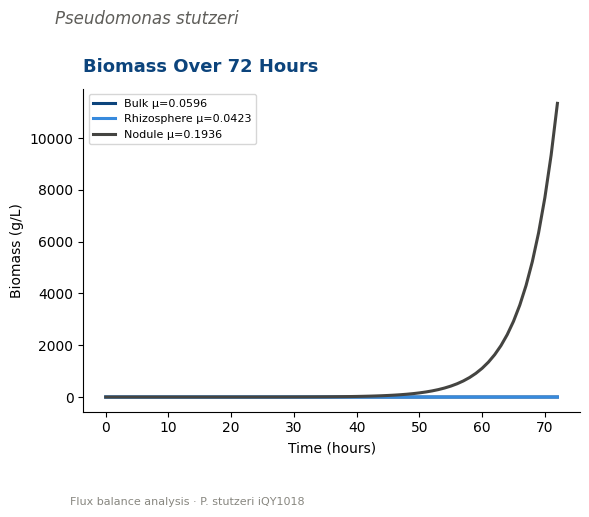

In [713]:
# Plot 2: biomass over time 
fig2, ax = plt.subplots(figsize=(6, 5))
for cond in conds:
    sub = time_df[time_df.condition == cond]
    mu = sub["mu"].iloc[0]
    ax.plot(sub.time_h, sub.biomass_gL, color=COLORS[cond], linewidth=2.2, label=f"{cond} µ={mu:.4f}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Biomass (g/L)")
ax.set_title("Biomass Over 72 Hours", fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig2.text(0.125, -0.04,
          "Flux balance analysis · P. stutzeri iQY1018",
          fontsize=8, color="#888780", ha="left")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig2.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig2.savefig(os.path.join(save_path, "2_biomass_over_time.png"), dpi=300)
plt.show()

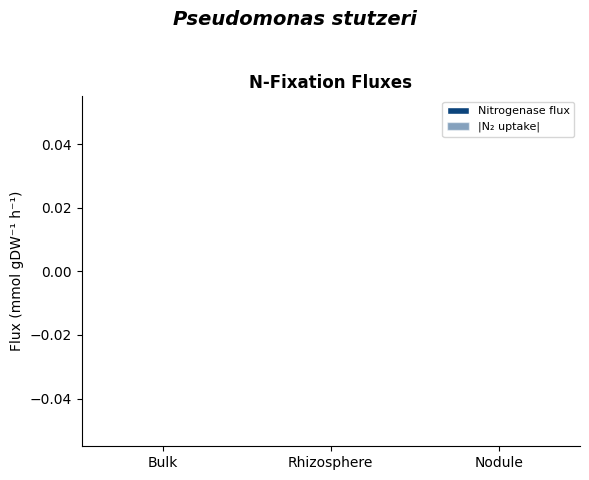

In [714]:
# Plot 3: nitrogenase + N2 uptake 
fig3, ax = plt.subplots(figsize=(6, 5))
nif_vals = summary_df["Nitrogenase_flux"].fillna(0).tolist()
n2_vals = summary_df["N2_uptake"].fillna(0).tolist()
x = np.arange(len(conds))
w = 0.35
ax.bar(x - w/2, nif_vals, width=w, label="Nitrogenase flux", color=[COLORS[c] for c in conds], edgecolor="white")
ax.bar(x + w/2, n2_vals, width=w, label="|N₂ uptake|", color=[COLORS[c] for c in conds], edgecolor="white", alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(conds)
ax.set_ylabel("Flux (mmol gDW⁻¹ h⁻¹)")
ax.set_title("N-Fixation Fluxes", fontweight="bold")
fig1.text(0.125, -0.04,
          "Flux balance analysis · P. stutzeri iQY1018",
          fontsize=8, color="#888780", ha="left")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig3.suptitle(species_name, fontsize=14, fontweight="bold", style='italic')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig3.savefig(os.path.join(save_path, "3_nitrogen_fluxes.png"), dpi=300)
plt.show()


In [715]:
print(f"Files saved in {save_path}:")
print("- 1_growth_rate.png")
print("- 2_biomass_over_time.png")
print("- 3_nitrogen_fluxes.png")

Files saved in Results_P_stutzeri_1018:
- 1_growth_rate.png
- 2_biomass_over_time.png
- 3_nitrogen_fluxes.png


find nitrogent fixation reaction

In [716]:
#model.metabolites.get_by_id('EX_cpd00528_e0').name

In [717]:
matches = [m for m in model.metabolites if 'n2' in m.name.lower()]
for m in matches:
    print(f"Metabolite ID: {m.id} | Name: {m.name}")

rxn_matches = [r for r in model.reactions if 'n2' in r.id.lower() or 'nitrogen' in r.name.lower()]
for r in rxn_matches:
    print(f"Reaction ID: {r.id} | Name: {r.name} | Formula: {r.reaction}")

Metabolite ID: cpd00030_e0 | Name: Mn2+
Metabolite ID: cpd00030_c0 | Name: Mn2+
Metabolite ID: cpd00034_c0 | Name: Zn2+
Metabolite ID: cpd02160_c0 | Name: N2-Succinyl-L-ornithine
Metabolite ID: cpd00528_c0 | Name: N2
Metabolite ID: cpd00034_e0 | Name: Zn2+
Reaction ID: rxn25164 | Name: succinyl-CoA:acetate CoA-transferase | Formula: cpd00029_c0 + cpd00078_c0 <=> cpd00022_c0 + cpd00036_c0
Reaction ID: rxn22447 | Name: N2O reductase(nosZ) | Formula: cpd00001_c0 + 2.0 cpd00109_c0 + cpd00528_c0 <=> 2.0 cpd00067_c0 + 2.0 cpd00110_c0 + cpd00659_c0
Reaction ID: rxn11937 | Name: Nitrogen:(NAD) oxidoreductase (N2O-forming) | Formula: cpd00004_c0 + cpd00067_c0 + cpd00659_c0 --> cpd00001_c0 + cpd00003_c0 + cpd00528_c0


In [718]:
# check nitrogen fixation reaction
nif_rxns = ["rxn06874_c0", "rxnNifS_c0", "rxnNifU", "symbiosis_c0",
            "EX_cpd00528_e0", "EX_cpdFixed_e0"]
print("\nNitrogen fixation reactions:")
for rid in nif_rxns:
    try:
        r = model.reactions.get_by_id(rid)
        print(f"{rid:30s} | {r.name}")
    except KeyError:
        print(f"{rid} — NOT FOUND")


Nitrogen fixation reactions:
rxn06874_c0 — NOT FOUND
rxnNifS_c0 — NOT FOUND
rxnNifU — NOT FOUND
symbiosis_c0 — NOT FOUND
EX_cpd00528_e0 — NOT FOUND
EX_cpdFixed_e0 — NOT FOUND


In [719]:

print("--- Searching by Name ---")
for r in model.reactions:
    if "nitrogen" in r.name.lower() or "n2" in r.id.lower():
        print(f"ID: {r.id} | Name: {r.name} | Formula: {r.reaction}")


print("\n--- Searching by Metabolite N2 ---")
try:
    n2_met = [m for m in model.metabolites if m.name.lower() == "n2" or m.id.lower() == "n2_e0"][0]
    for r in n2_met.reactions:
        print(f"ID: {r.id} | Name: {r.name} | Formula: {r.reaction}")
except IndexError:
    print("N2 metabolite not found with that name.")

--- Searching by Name ---
ID: rxn25164 | Name: succinyl-CoA:acetate CoA-transferase | Formula: cpd00029_c0 + cpd00078_c0 <=> cpd00022_c0 + cpd00036_c0
ID: rxn22447 | Name: N2O reductase(nosZ) | Formula: cpd00001_c0 + 2.0 cpd00109_c0 + cpd00528_c0 <=> 2.0 cpd00067_c0 + 2.0 cpd00110_c0 + cpd00659_c0
ID: rxn11937 | Name: Nitrogen:(NAD) oxidoreductase (N2O-forming) | Formula: cpd00004_c0 + cpd00067_c0 + cpd00659_c0 --> cpd00001_c0 + cpd00003_c0 + cpd00528_c0

--- Searching by Metabolite N2 ---
ID: EX_cpd00528_c0 | Name:  | Formula: cpd00528_c0 --> 
ID: rxn11937 | Name: Nitrogen:(NAD) oxidoreductase (N2O-forming) | Formula: cpd00004_c0 + cpd00067_c0 + cpd00659_c0 --> cpd00001_c0 + cpd00003_c0 + cpd00528_c0
ID: rxn22447 | Name: N2O reductase(nosZ) | Formula: cpd00001_c0 + 2.0 cpd00109_c0 + cpd00528_c0 <=> 2.0 cpd00067_c0 + 2.0 cpd00110_c0 + cpd00659_c0


set environment for fix nitrogen

create nitrogen fixation reaction

In [720]:
fixation = Reaction("N2_FIX_CUSTOM")
fixation.name = "Nitrogen fixation (Nitrogenase)"
fixation.lower_bound = 0.   
fixation.upper_bound = 1000.
fixation.add_metabolites({
    model.metabolites.get_by_id("cpd00528_c0"): -1.0,
    model.metabolites.get_by_id("cpd00067_c0"): -8.0,
    model.metabolites.get_by_id("cpd00002_c0"): -16.0,
    model.metabolites.get_by_id("cpd00013_c0"): 2.0,
    model.metabolites.get_by_id("cpd00008_c0"): 16.0,
    model.metabolites.get_by_id("cpd00009_c0"): 16.0,
    model.metabolites.get_by_id("cpd00011_c0"): 1.0
})

model.add_reactions([fixation])
print(f"Reaction added: {fixation.reaction}")

Reaction added: 16.0 cpd00002_c0 + 8.0 cpd00067_c0 + cpd00528_c0 --> 16.0 cpd00008_c0 + 16.0 cpd00009_c0 + cpd00011_c0 + 2.0 cpd00013_c0


calculate optimization

how bacteria fix nitrogen to growth 

In [721]:
n2_fixation_id = "N2_FIX_CUSTOM"
n2_result_summary = []

for cond_name, sol, model_cond in [
        ("bulk",         solution_bulk, model_bulk),
        ("rhizosphere", solution_rh,   model_rh),
        ("nodule",       solution_no,   model_no),
]:
    if sol.status != "optimal":
        print(f"  {cond_name}: skipped (infeasible)")
        continue

    flux_df = sol.to_frame().reset_index()
    flux_df.columns = ["reaction_id", "flux", "reduced_cost"]

    # find nitrogen fixation 
    if n2_fixation_id in sol.fluxes:
        n2_flux = sol.fluxes[n2_fixation_id]
        n2_result_summary.append({
            "condition": cond_name,
            "n2_fixation_flux": n2_flux,
            "status": sol.status
        })
    else:
        print(f"  Warning: {n2_fixation_id} not found in {cond_name} model")

    flux_df["reaction_name"] = flux_df["reaction_id"].apply(
        lambda rid: model_cond.reactions.get_by_id(rid).name
        if rid in model_cond.reactions else ""
    )
    flux_df.insert(0, "condition", cond_name)

    fname = os.path.join(save_path, f"{cond_name}_fluxes.tsv")
    flux_df.to_csv(fname, sep="\t", index=False)
    print(f"  Saved {cond_name} fluxes with N2 Fixation rate: {n2_flux if n2_fixation_id in sol.fluxes else 'N/A'}")

summary_df = pd.DataFrame(n2_result_summary)
print("\n--- Nitrogen Fixation Summary ---")
print(summary_df)

  Saved bulk fluxes with N2 Fixation rate: N/A
  Saved rhizosphere fluxes with N2 Fixation rate: N/A
  Saved nodule fluxes with N2 Fixation rate: N/A

--- Nitrogen Fixation Summary ---
Empty DataFrame
Columns: []
Index: []


maximum

nitrogen fixation objective == how maximum bacteria can fix nitrogen only

In [722]:
max_n2_results = []

conditions = [
    ("bulk", model_bulk),
    ("rhizosphere", model_rh),
    ("nodule", model_no)
]

print("\n--- Calculating Theoretical Maximum N2 Fixation ---")

for cond_name, model_orig in conditions:
    with model_orig as temp_model:
        if n2_fixation_id in temp_model.reactions:
            # nitrogen fixation only
            temp_model.objective = n2_fixation_id
            sol = temp_model.optimize()

            if sol.status == "optimal":
                max_val = sol.objective_value
                print(f"  {cond_name:12s}: Max N2 Fixation = {max_val:.6f}")

                max_n2_results.append({
                    "condition": cond_name,
                    "max_n2_flux": max_val,
                    "status": sol.status
                })

                flux_df = sol.to_frame().reset_index()
                flux_df.insert(0, "condition", f"{cond_name}_max_n2")
                fname = os.path.join(save_path, f"{cond_name}_max_n2_fluxes.tsv")
                flux_df.to_csv(fname, sep="\t", index=False)
            else:
                print(f"  {cond_name:12s}: Infeasible (อาจขาดพลังงาน ATP หรือ H2)")
        else:
            print(f"  {cond_name:12s}: Reaction {n2_fixation_id} not found")

summary_max_df = pd.DataFrame(max_n2_results)
print("\nSummary Table:")
print(summary_max_df)


--- Calculating Theoretical Maximum N2 Fixation ---
  bulk        : Reaction N2_FIX_CUSTOM not found
  rhizosphere : Reaction N2_FIX_CUSTOM not found
  nodule      : Reaction N2_FIX_CUSTOM not found

Summary Table:
Empty DataFrame
Columns: []
Index: []


list all save files

In [723]:
import glob
print(f"\nChecking saved files in {save_path}/")
files = sorted(glob.glob(os.path.join(save_path, "*")))
for f in files:
    size = os.path.getsize(f)
    print(f"  {os.path.basename(f):45s} | {size:>10,} bytes")


Checking saved files in Results_P_stutzeri_1018/
  1_growth_rate.png                             |    104,593 bytes
  2_biomass_over_time.png                       |    107,565 bytes
  3_nitrogen_fluxes.png                         |     73,655 bytes
  P_stutzeri_1018_metabolites_for_mapping.csv   |     62,483 bytes
  P_stutzeri_1018_reactions_for_mapping.csv     |    179,044 bytes
  Renamed_P_stutzeri_1018.xml                   |  5,698,713 bytes
  biomass_over_time.tsv                         |      9,679 bytes
  boundary_list.txt                             |     12,646 bytes
  boundary_reactions.csv                        |      4,053 bytes
  boundary_reactions.tsv                        |      4,053 bytes
  bulk_fluxes.tsv                               |    109,902 bytes
  bulk_genes.tsv                                |     45,339 bytes
  exchange_fluxes_all_conditions.tsv            |      2,479 bytes
  growth_rate_summary.tsv                       |        516 bytes
  nodule_flu